# Database Benchmark Analysis

This notebook analyzes and visualizes the results from comprehensive database benchmarking tests across MySQL, PostgreSQL, MongoDB, and Redis.

## Overview
- **Objective**: Compare performance of different database systems under various conditions
- **Databases Tested**: MySQL, PostgreSQL, MongoDB, Redis
- **Data Scales**: 500K, 1M, 10M records
- **Operations**: SELECT/FIND/GET (read), INSERT/SET (create), UPDATE (modify), DELETE/DEL (remove)
- **Trials**: 3 trials per benchmark scenario
- **Scenario count**: 24+ distinct scenarios (meets Grade 4.0 requirements)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import os
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Color palettes
DB_COLORS = {
    'mysql':      '#00758f',
    'postgresql': '#336791',
    'mongodb':    '#13aa52',
    'redis':      '#dc382d',
}

OP_COLORS = {
    'read':   '#2ecc71',
    'create': '#3498db',
    'update': '#f39c12',
    'delete': '#e74c3c',
}

print('Libraries loaded.')

Libraries loaded.


## 2. Load Benchmark Results

In [2]:
results_dir = Path('../results')

csv_files = sorted(results_dir.glob('benchmark_results_*.csv'))
json_files = sorted(results_dir.glob('benchmark_results_*.json'))

if not csv_files:
    raise FileNotFoundError('No CSV result files found in ../results/')

latest_csv = csv_files[-1]
print(f'Loading: {latest_csv.name}')
df_raw = pd.read_csv(latest_csv)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

# Normalize operation names to CRUD categories
READ_OPS   = {'select', 'find', 'get'}
CREATE_OPS = {'insert', 'insertone', 'set'}
UPDATE_OPS = {'update', 'updateone'}
DELETE_OPS = {'delete', 'deleteone', 'del'}

def normalize_op(op):
    op_lower = str(op).lower()
    if op_lower in READ_OPS:   return 'read'
    if op_lower in CREATE_OPS: return 'create'
    if op_lower in UPDATE_OPS: return 'update'
    if op_lower in DELETE_OPS: return 'delete'
    return op_lower

df_raw['crud_op'] = df_raw['operation'].apply(normalize_op)

# Remove extreme outliers (QPS < 10 or > 1_000_000)
df = df_raw[(df_raw['queries_per_second'] >= 10) & (df_raw['queries_per_second'] <= 1_000_000)].copy()
print(f'After outlier filter: {len(df)} rows (removed {len(df_raw)-len(df)})')

print('\nUnique operations:', df['operation'].unique())
print('CRUD categories:  ', df['crud_op'].unique())
print('Databases:        ', df['database'].unique())
print('Data scales:      ', sorted(df['data_scale'].unique()))

Loading: benchmark_results_LATEST.csv
Shape: (732, 11)
Columns: ['database', 'entity', 'operation', 'batch_size', 'data_scale', 'trial', 'num_queries', 'total_time_ms', 'avg_time_per_op_ms', 'queries_per_second', 'with_index']
After outlier filter: 729 rows (removed 3)

Unique operations: <StringArray>
[   'select',    'insert',    'update',    'delete',      'find', 'insertOne',
 'updateOne', 'deleteOne',       'get',       'set',       'del']
Length: 11, dtype: str
CRUD categories:   <StringArray>
['read', 'create', 'update', 'delete']
Length: 4, dtype: str
Databases:         <StringArray>
['mysql', 'postgresql', 'mongodb', 'redis']
Length: 4, dtype: str
Data scales:       [np.int64(500000), np.int64(1000000), np.int64(10000000)]


## 3. Summary Statistics

In [3]:
print('=' * 70)
print('PERFORMANCE SUMMARY BY DATABASE AND CRUD OPERATION')
print('=' * 70)

summary = df.groupby(['database', 'crud_op'])['queries_per_second'].agg(['mean', 'std', 'count']).round(1)
print(summary.to_string())

print('\n' + '=' * 70)
print('SCENARIO COUNT (database × operation × data_scale)')
print('=' * 70)
scenario_count = df.groupby(['database', 'operation'])['queries_per_second'].count()
print(scenario_count)
total_scenarios = df[['database', 'entity', 'operation']].drop_duplicates().shape[0]
print(f'\nTotal distinct scenarios: {total_scenarios}')

PERFORMANCE SUMMARY BY DATABASE AND CRUD OPERATION
                      mean     std  count
database   crud_op                       
mongodb    create   6536.3   124.8     27
           delete   4853.8   286.1     27
           read     4485.6  1157.0     27
           update   5911.8   115.1     27
mysql      create   8146.1   333.0     60
           delete   6476.3  3192.3     60
           read     3824.3  2195.5     57
           update   6319.2  3100.7     60
postgresql create   7576.8   239.1     60
           delete   7181.6  1261.1     60
           read     3796.2  2351.7     60
           update   4372.1   548.9     60
redis      create   8203.6   333.2     36
           delete   8547.0   419.4     36
           read     8392.3   637.0     36
           update   8351.9   456.8     36

SCENARIO COUNT (database × operation × data_scale)
database    operation
mongodb     deleteOne    27
            find         27
            insertOne    27
            updateOne    27
mysql  

## 4. Visualizations

### 4.1 Average QPS by Database (all operations)

/var/folders/yh/wcj04z8j4cx217b0cwf7b1_w0000gp/T/ipykernel_31805/756577522.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([d.upper() for d in db_qps.index])


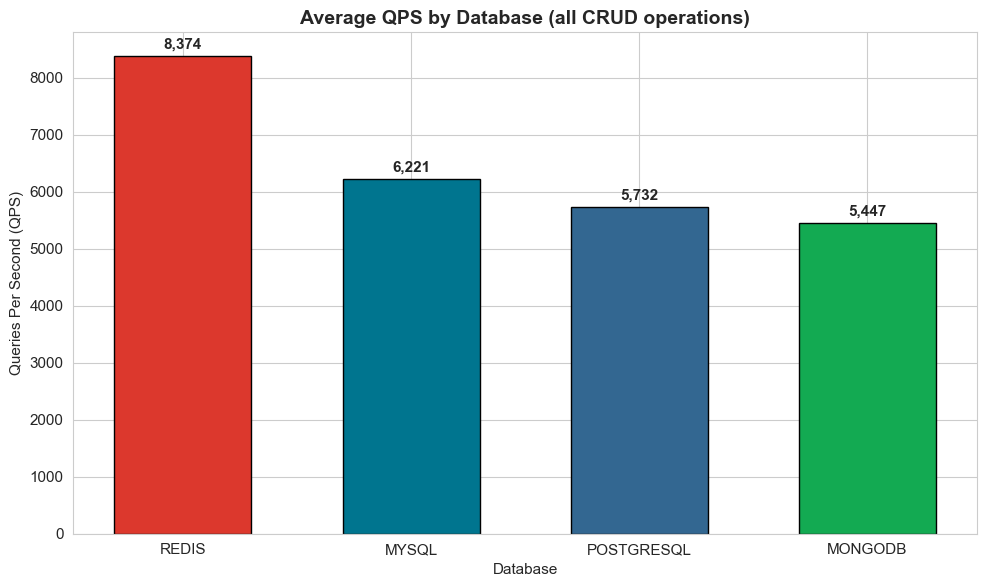

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

db_qps = df.groupby('database')['queries_per_second'].mean().sort_values(ascending=False)
bars = ax.bar(
    db_qps.index,
    db_qps.values,
    color=[DB_COLORS.get(db, '#999') for db in db_qps.index],
    edgecolor='black', width=0.6
)

for bar, val in zip(bars, db_qps.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(db_qps)*0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Average QPS by Database (all CRUD operations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Database')
ax.set_xticklabels([d.upper() for d in db_qps.index])
plt.tight_layout()
plt.savefig('chart_01_avg_qps_by_db.png', dpi=150)
plt.show()

### 4.2 CRUD Operation Comparison per Database

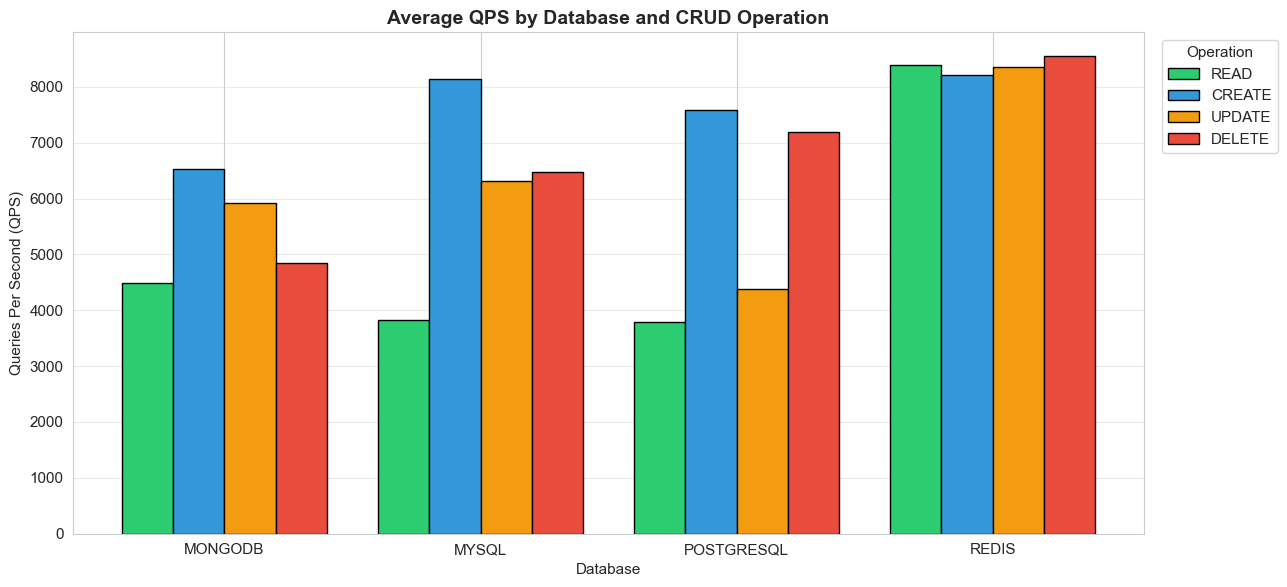

In [5]:
crud_order = ['read', 'create', 'update', 'delete']
existing_ops = [op for op in crud_order if op in df['crud_op'].unique()]

pivot = df.groupby(['database', 'crud_op'])['queries_per_second'].mean().unstack(fill_value=np.nan)
pivot = pivot.reindex(columns=[c for c in crud_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(pivot.index))
width = 0.2
offsets = np.linspace(-(len(existing_ops)-1)/2, (len(existing_ops)-1)/2, len(existing_ops)) * width

for i, op in enumerate(existing_ops):
    if op not in pivot.columns:
        continue
    bars = ax.bar(x + offsets[i], pivot[op], width, label=op.upper(),
                  color=OP_COLORS.get(op, '#aaa'), edgecolor='black')

ax.set_title('Average QPS by Database and CRUD Operation', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Database')
ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in pivot.index])
ax.legend(title='Operation', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_02_crud_by_db.png', dpi=150)
plt.show()

### 4.3 Performance by Data Scale per Database

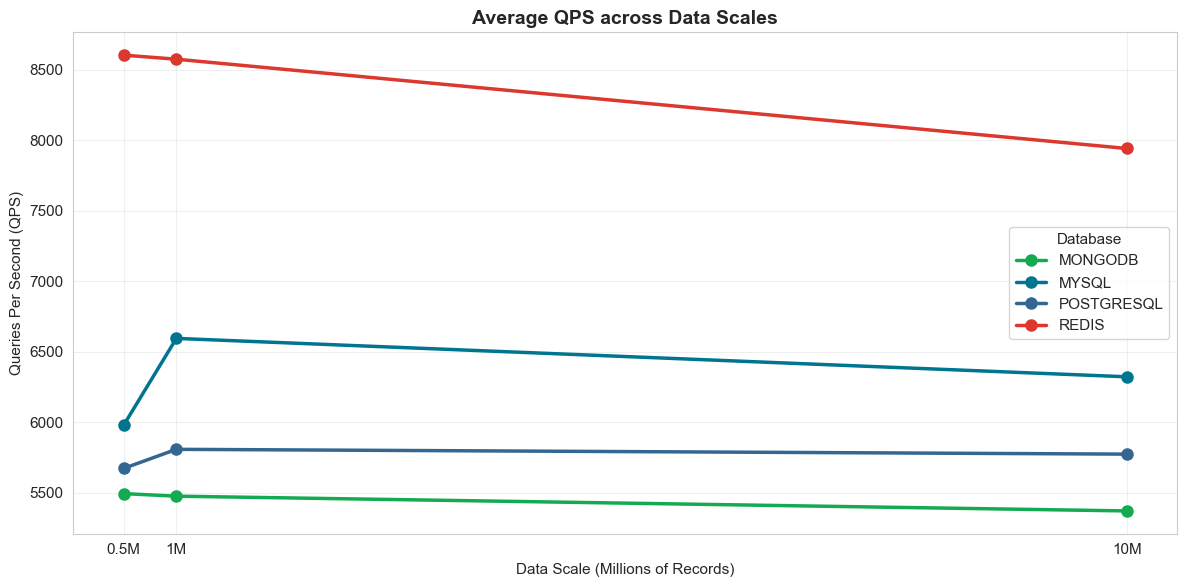

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for db in sorted(df['database'].unique()):
    db_data = df[df['database'] == db].groupby('data_scale')['queries_per_second'].mean().sort_index()
    ax.plot(db_data.index / 1_000_000, db_data.values,
            marker='o', label=db.upper(), linewidth=2.5, markersize=8,
            color=DB_COLORS.get(db))

ax.set_title('Average QPS across Data Scales', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Data Scale (Millions of Records)')
ax.set_xticks([0.5, 1.0, 10.0])
ax.set_xticklabels(['0.5M', '1M', '10M'])
ax.legend(title='Database', loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart_03_scale_impact.png', dpi=150)
plt.show()

### 4.4 Data Scale Impact per CRUD Operation

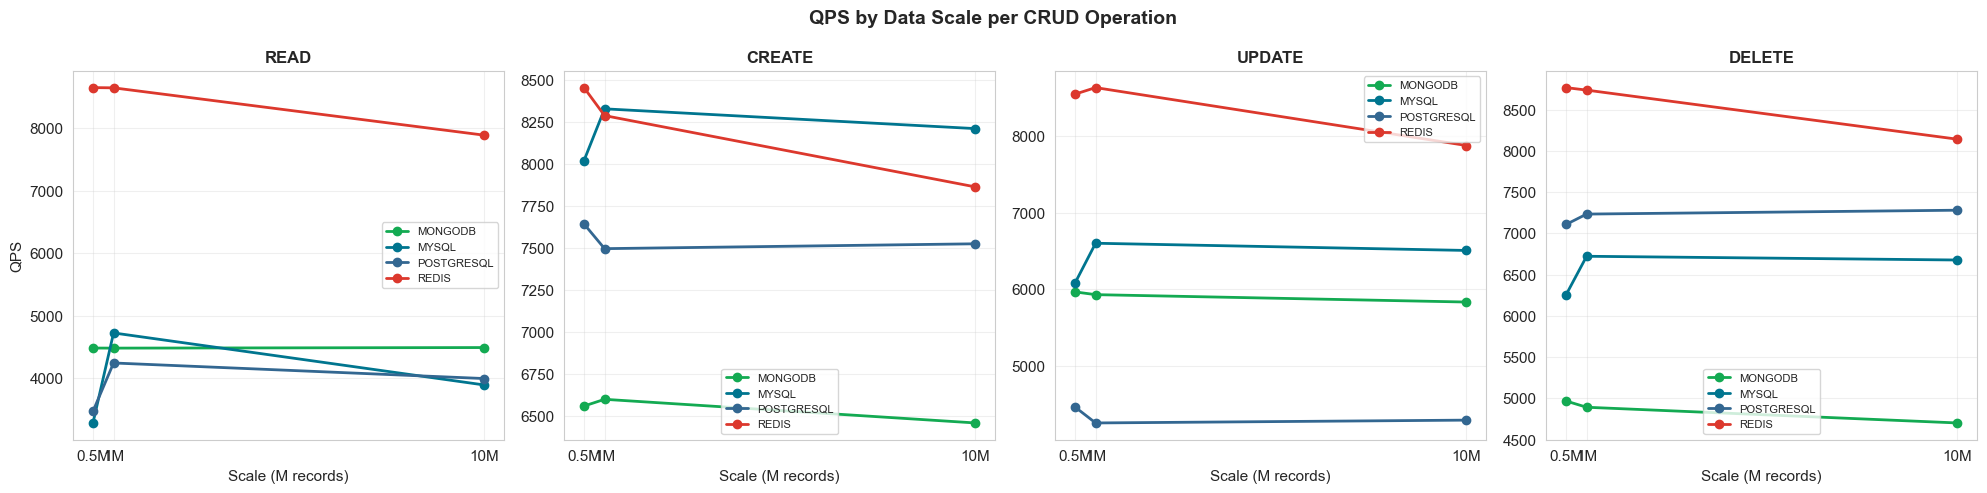

In [7]:
ops_present = [op for op in crud_order if op in df['crud_op'].unique()]
n_ops = len(ops_present)
fig, axes = plt.subplots(1, n_ops, figsize=(5*n_ops, 5), sharey=False)
if n_ops == 1:
    axes = [axes]

for ax, op in zip(axes, ops_present):
    op_data = df[df['crud_op'] == op]
    for db in sorted(op_data['database'].unique()):
        d = op_data[op_data['database'] == db].groupby('data_scale')['queries_per_second'].mean().sort_index()
        ax.plot(d.index / 1_000_000, d.values, marker='o', label=db.upper(),
                linewidth=2, color=DB_COLORS.get(db))
    ax.set_title(f'{op.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Scale (M records)')
    ax.set_ylabel('QPS' if op == ops_present[0] else '')
    ax.set_xticks([0.5, 1.0, 10.0])
    ax.set_xticklabels(['0.5M', '1M', '10M'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('QPS by Data Scale per CRUD Operation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_scale_per_crud.png', dpi=150)
plt.show()

### 4.5 Index Impact — All CRUD (MySQL & PostgreSQL)

Hipoteza H1 z regulaminu: *indeksy poprawiają wydajność SELECT, ale obniżają wydajność operacji modyfikujących (INSERT/UPDATE/DELETE)*.
Teraz każdy CRUD jest testowany w dwóch fazach — bez indeksów i z indeksami — więc możemy to bezpośrednio sprawdzić.

Average QPS — Index impact across CRUD operations:
                    Without index  With index
database   crud_op                           
mysql      create          8069.1      8171.8
           delete          6289.0      6538.7
           read            1563.6      4427.2
           update          6053.8      6407.6
postgresql create          7660.8      7548.8
           delete          7202.6      7174.7
           read            2473.3      4237.1
           update          4573.0      4305.1

% change with index (positive = faster):
  MYSQL        create : +1.3%
  MYSQL        delete : +4.0%
  MYSQL        read   : +183.1%
  MYSQL        update : +5.8%
  POSTGRESQL   create : -1.5%
  POSTGRESQL   delete : -0.4%
  POSTGRESQL   read   : +71.3%
  POSTGRESQL   update : -5.9%


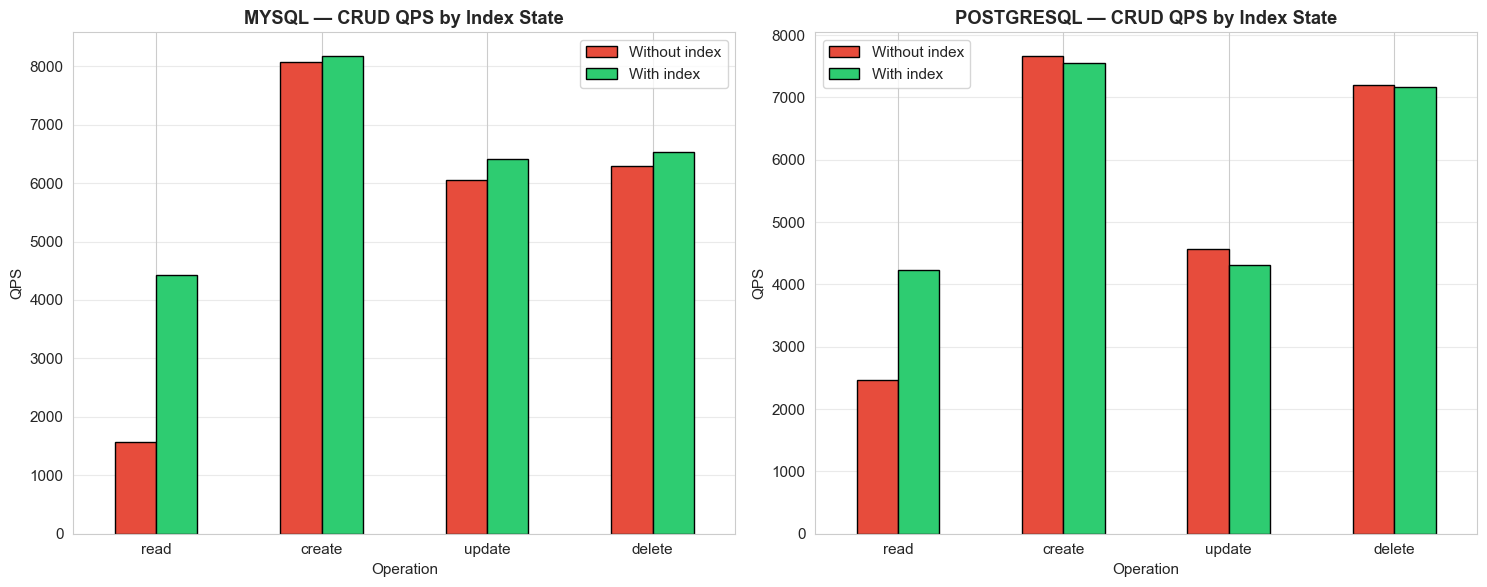

In [8]:
sql_indexed = df[
    df['database'].isin(['mysql', 'postgresql']) &
    df['with_index'].notna()
].copy()

if sql_indexed.empty:
    print('No SQL with_index data available.')
else:
    summary = (sql_indexed
        .groupby(['database', 'crud_op', 'with_index'])['queries_per_second']
        .mean()
        .unstack('with_index'))
    summary.columns = ['Without index' if c == False else 'With index' for c in summary.columns]
    print('Average QPS — Index impact across CRUD operations:')
    print(summary.round(1).to_string())

    # % change with index
    if 'Without index' in summary.columns and 'With index' in summary.columns:
        pct = ((summary['With index'] - summary['Without index']) /
               summary['Without index'] * 100)
        print('\n% change with index (positive = faster):')
        for (db, op), v in pct.items():
            sign = '+' if v >= 0 else ''
            print(f'  {db.upper():12s} {op:7s}: {sign}{v:.1f}%')

    # Grouped bar: rows = (db, crud), bars = with/without index
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
    for ax, db in zip(axes, ['mysql', 'postgresql']):
        d = sql_indexed[sql_indexed['database'] == db]
        if d.empty:
            ax.set_title(f'{db.upper()} (no data)')
            continue
        pivot = d.groupby(['crud_op', 'with_index'])['queries_per_second'].mean().unstack()
        pivot = pivot.reindex(index=[op for op in ['read','create','update','delete'] if op in pivot.index])
        pivot.columns = ['Without index' if c == False else 'With index' for c in pivot.columns]
        pivot.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
        ax.set_title(f'{db.upper()} — CRUD QPS by Index State', fontweight='bold')
        ax.set_xlabel('Operation')
        ax.set_ylabel('QPS')
        ax.grid(axis='y', alpha=0.4)
        plt.setp(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig('chart_05_index_impact.png', dpi=150)
    plt.show()


### 4.6 Heatmap: Average QPS — Database × CRUD Operation

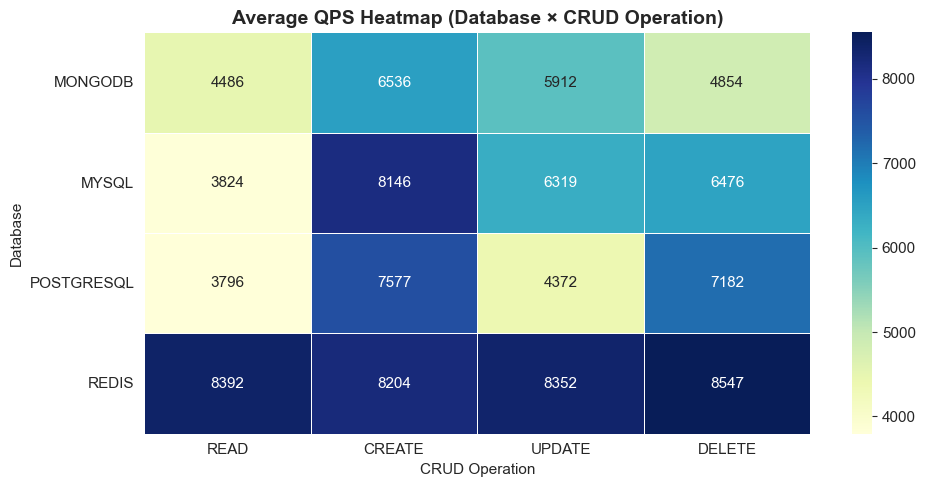

In [9]:
pivot_heat = df.groupby(['database', 'crud_op'])['queries_per_second'].mean().unstack()
pivot_heat = pivot_heat.reindex(columns=[c for c in crud_order if c in pivot_heat.columns])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_heat, annot=True, fmt='.0f',
    cmap='YlGnBu', ax=ax, linewidths=0.5,
    annot_kws={'size': 11}
)
ax.set_title('Average QPS Heatmap (Database × CRUD Operation)', fontsize=14, fontweight='bold')
ax.set_xlabel('CRUD Operation')
ax.set_ylabel('Database')
ax.set_xticklabels([c.upper() for c in pivot_heat.columns], rotation=0)
ax.set_yticklabels([d.upper() for d in pivot_heat.index], rotation=0)
plt.tight_layout()
plt.savefig('chart_06_heatmap_crud.png', dpi=150)
plt.show()

### 4.7 Variability (Coefficient of Variation) per Database

/var/folders/yh/wcj04z8j4cx217b0cwf7b1_w0000gp/T/ipykernel_31805/3480800950.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[d.upper() for d in db_order], patch_artist=True, notch=False)


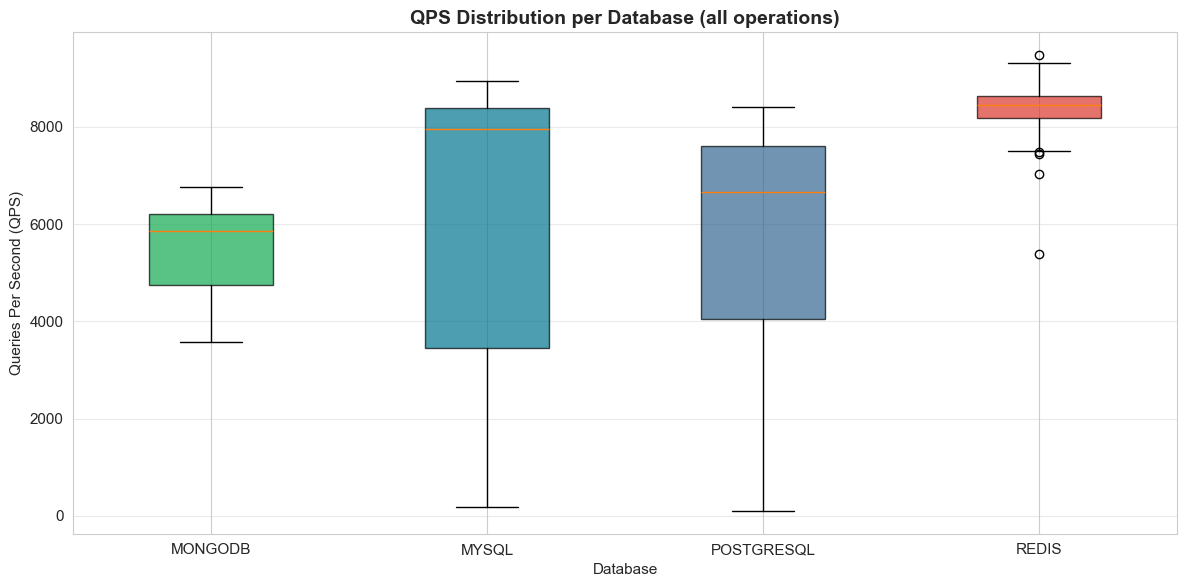

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

db_order = sorted(df['database'].unique())
data_to_plot = [df[df['database'] == db]['queries_per_second'].values for db in db_order]

bp = ax.boxplot(data_to_plot, labels=[d.upper() for d in db_order], patch_artist=True, notch=False)
for patch, db in zip(bp['boxes'], db_order):
    patch.set_facecolor(DB_COLORS.get(db, '#aaa'))
    patch.set_alpha(0.7)

ax.set_title('QPS Distribution per Database (all operations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Queries Per Second (QPS)')
ax.set_xlabel('Database')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_07_boxplot_db.png', dpi=150)
plt.show()

## 5. Analiza planów zapytań (EXPLAIN)

Optymalizator wybiera ścieżkę dostępu na podstawie statystyk tabeli.
Po dodaniu indeksu na kolumnę z `WHERE` plan zmienia się z pełnego skanu
(`type=ALL` w MySQL / `Seq Scan` w Postgres) na dostęp przez indeks
(`type=ref` / `Index Scan` lub `Bitmap Index Scan`).

Plany zostały zebrane przy największej skali danych (10M rekordów).

In [11]:
import json
from pathlib import Path

explain_path = Path('explain_plans.json')
if not explain_path.exists():
    print('explain_plans.json not found — run the benchmark first to generate it.')
    explain_plans = []
else:
    with explain_path.open() as f:
        explain_plans = json.load(f) or []
    print(f'Loaded {len(explain_plans)} EXPLAIN plans.')

explain_df = pd.DataFrame(explain_plans)
if not explain_df.empty:
    print('\nScenarios with EXPLAIN data:')
    print(explain_df.groupby(['database', 'with_index']).size().to_string())

Loaded 20 EXPLAIN plans.

Scenarios with EXPLAIN data:
database    with_index
mysql       False         5
            True          5
postgresql  False         5
            True          5


In [12]:
# Per (database, entity) pairing — show with/without index plans side by side.
if explain_df.empty:
    print('No EXPLAIN data to summarise.')
else:
    for (db, ent), group in explain_df.groupby(['database', 'entity']):
        print('=' * 78)
        print(f'{db.upper()} · {ent}')
        print('=' * 78)
        for _, row in group.sort_values('with_index').iterrows():
            label = 'WITH INDEX' if row['with_index'] else 'WITHOUT INDEX'
            print(f'\n--- {label} ---')
            print(f'Query: {row["query"]}')
            print(f'Plan:\n{row["plan"]}')

MYSQL · addresses

--- WITHOUT INDEX ---
Query: SELECT * FROM addresses WHERE postal_code = '63408' LIMIT 100
Plan:
id | select_type | table | partitions | type | possible_keys | key | key_len | ref | rows | filtered | Extra
------------------------------------------------------------------------------------------------------------
1 | SIMPLE | addresses | NULL | ALL | NULL | NULL | NULL | NULL | 497160 | 10 | Using where


--- WITH INDEX ---
Query: SELECT * FROM addresses WHERE postal_code = '63408' LIMIT 100
Plan:
id | select_type | table | partitions | type | possible_keys | key | key_len | ref | rows | filtered | Extra
------------------------------------------------------------------------------------------------------------
1 | SIMPLE | addresses | NULL | ref | idx_addresses_postal_code | idx_addresses_postal_code | 83 | const | 104 | 100 | NULL

MYSQL · categories

--- WITHOUT INDEX ---
Query: SELECT * FROM categories WHERE display_order = 1 LIMIT 100
Plan:
id | select_type | ta

In [13]:
# Compact comparison: first significant token of each plan side-by-side.
# For MySQL this is the `type` column (ALL, ref, range, index, ...).
# For Postgres this is the top-level node (Seq Scan, Index Scan, Bitmap Heap Scan, ...).
import re

def access_path(db, plan):
    if not isinstance(plan, str):
        return ''
    lines = [ln for ln in plan.splitlines() if ln.strip() and not set(ln.strip()) <= {'-'}]
    if db == 'mysql':
        if len(lines) < 2:
            return ''
        header = [c.strip() for c in lines[0].split('|')]
        data = [c.strip() for c in lines[1].split('|')]
        if 'type' in header:
            return data[header.index('type')]
        return data[3] if len(data) > 3 else ''
    if db == 'postgresql':
        m = re.match(r'\s*([\w ]+?)\s+(on|using|\()', lines[0])
        return m.group(1).strip() if m else lines[0].strip().split('(')[0].strip()
    return ''

if not explain_df.empty:
    explain_df['access_path'] = explain_df.apply(lambda r: access_path(r['database'], r['plan']), axis=1)
    pivot = explain_df.pivot_table(
        index=['database', 'entity'],
        columns='with_index',
        values='access_path',
        aggfunc='first',
    ).rename(columns={False: 'Without index', True: 'With index'})
    print('Access path: without vs. with index')
    print(pivot.to_string())

Access path: without vs. with index
with_index            Without index With index
database   entity                             
mysql      addresses            ALL        ref
           categories           ALL        ref
           orders               ALL        ref
           products             ALL        ref
           users                ALL        ref
postgresql addresses          Limit      Limit
           categories         Limit      Limit
           orders             Limit      Limit
           products           Limit      Limit
           users              Limit      Limit


## 6. Key Findings

In [14]:
print('=' * 70)
print('KEY FINDINGS')
print('=' * 70)

# 1. Overall ranking
print('\n1. OVERALL DATABASE RANKING (avg QPS all operations):')
ranking = df.groupby('database')['queries_per_second'].agg(['mean','std']).sort_values('mean', ascending=False)
for i, (db, row) in enumerate(ranking.iterrows(), 1):
    print(f'   #{i}. {db.upper()}: {row["mean"]:,.1f} ± {row["std"]:,.1f} QPS')

# 2. Fastest per CRUD
print('\n2. FASTEST DATABASE PER CRUD OPERATION:')
for op in crud_order:
    op_df = df[df['crud_op'] == op]
    if op_df.empty:
        continue
    best_db = op_df.groupby('database')['queries_per_second'].mean().idxmax()
    best_qps = op_df.groupby('database')['queries_per_second'].mean().max()
    print(f'   {op.upper():8s}: {best_db.upper()} ({best_qps:,.1f} QPS)')

# 3. Data scale impact
print('\n3. IMPACT OF DATA SCALE ON QPS:')
scale_perf = df.groupby('data_scale')['queries_per_second'].mean().sort_index()
first, last = scale_perf.iloc[0], scale_perf.iloc[-1]
change = (last - first) / first * 100
for scale, qps in scale_perf.items():
    print(f'   {scale/1e6:.1f}M records: {qps:,.1f} QPS')
print(f'   Change 0.5M → 10M: {change:+.1f}%')

# 4. Index impact
sql_read = df[df['database'].isin(['mysql','postgresql']) & (df['crud_op']=='read')]
if not sql_read.empty:
    print('\n4. INDEX IMPACT (SQL SELECT):')
    for db in ['mysql', 'postgresql']:
        d = sql_read[sql_read['database'] == db]
        no_idx = d[d['with_index'] == False]['queries_per_second'].mean()
        wi_idx = d[d['with_index'] == True]['queries_per_second'].mean()
        chg = (wi_idx - no_idx) / no_idx * 100
        print(f'   {db.upper()}: without={no_idx:,.1f} with={wi_idx:,.1f} ({chg:+.1f}%)')

# 5. Consistency
print('\n5. CONSISTENCY (Coefficient of Variation):')
for db in sorted(df['database'].unique()):
    d = df[df['database'] == db]['queries_per_second']
    cv = d.std() / d.mean() * 100
    label = 'Very Stable' if cv < 15 else ('Moderate' if cv < 30 else 'High Variance')
    print(f'   {db.upper():12s}: CV={cv:.1f}% ({label})')

print('\n' + '=' * 70)

KEY FINDINGS

1. OVERALL DATABASE RANKING (avg QPS all operations):
   #1. REDIS: 8,373.7 ± 485.4 QPS
   #2. MYSQL: 6,221.5 ± 2,910.6 QPS
   #3. POSTGRESQL: 5,731.7 ± 2,152.5 QPS
   #4. MONGODB: 5,446.9 ± 1,014.0 QPS

2. FASTEST DATABASE PER CRUD OPERATION:
   READ    : REDIS (8,392.3 QPS)
   CREATE  : REDIS (8,203.6 QPS)
   UPDATE  : REDIS (8,351.9 QPS)
   DELETE  : REDIS (8,547.0 QPS)

3. IMPACT OF DATA SCALE ON QPS:
   0.5M records: 6,202.2 QPS
   1.0M records: 6,631.9 QPS
   10.0M records: 6,374.3 QPS
   Change 0.5M → 10M: +2.8%

4. INDEX IMPACT (SQL SELECT):
   MYSQL: without=1,563.6 with=4,427.2 (+183.1%)
   POSTGRESQL: without=2,473.3 with=4,237.1 (+71.3%)

5. CONSISTENCY (Coefficient of Variation):
   MONGODB     : CV=18.6% (Moderate)
   MYSQL       : CV=46.8% (High Variance)
   POSTGRESQL  : CV=37.6% (High Variance)
   REDIS       : CV=5.8% (Very Stable)



## 7. Export Summary Reports

In [15]:
# Summary by database
summary_export = df.groupby('database').agg(
    avg_qps=('queries_per_second', 'mean'),
    std_qps=('queries_per_second', 'std'),
    avg_time_ms=('avg_time_per_op_ms', 'mean'),
    total_tests=('queries_per_second', 'count'),
).round(4)
summary_export.to_csv('summary_report.csv')
print(f'Summary exported → summary_report.csv')

# Per database CSV files
for db in df['database'].unique():
    db_data = df[df['database'] == db]
    db_data.to_csv(f'{db}_results.csv', index=False)
    print(f'{db.upper()} exported → {db}_results.csv')

# Top performers
top = df.nlargest(20, 'queries_per_second')[[
    'database', 'entity', 'operation', 'crud_op', 'data_scale', 'queries_per_second', 'avg_time_per_op_ms'
]]
top.to_csv('top_performers.csv', index=False)
print(f'Top performers exported → top_performers.csv')

# CRUD summary
crud_summary = df.groupby(['database', 'crud_op', 'data_scale'])['queries_per_second'].agg(['mean','std','count']).round(2)
crud_summary.to_csv('crud_summary.csv')
print(f'CRUD summary exported → crud_summary.csv')

print('\nAll exports complete.')

Summary exported → summary_report.csv
MYSQL exported → mysql_results.csv
POSTGRESQL exported → postgresql_results.csv
MONGODB exported → mongodb_results.csv
REDIS exported → redis_results.csv
Top performers exported → top_performers.csv
CRUD summary exported → crud_summary.csv

All exports complete.
